# QBF Solver Analysis Notebook

This notebook creates all scientific plots for the bachelor thesis.

**Main goal:** analyse how truth-preserving QBF transformations influence solver behavior.

The notebook covers:
1. Data loading
2. Data cleaning and validity filtering
3. Correctness check: equivalence rate
4. Runtime analysis
5. Coverage analysis
6. Solver comparison: DepQBF vs. CAQE
7. Secondary analysis: coverage change vs. runtime effect
8. Export of all plots as PNG files


## 1. Imports and Global Configuration

In [114]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

RESULTS_CSV = Path("results/experiments.csv")
PLOT_DIR = Path("thesis-template/thesis/images")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DPI = 300
FIGURE_WIDTH = 12
FIGURE_HEIGHT = 6

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": FIGURE_DPI,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print("Notebook configuration loaded.")

Notebook configuration loaded.


## 2. Operator Configuration

The operators are ordered by their intended solver mechanism.

In [115]:
OPERATOR_COLORS = {
    "tautology_insertion": "#4C72B0",
    "pure_literal_gen_auto": "#DD8452",
    "pure_literal_gen_pos": "#E8A070",
    "pure_literal_gen_neg": "#C4633A",
    "universal_reduction_trigger": "#55A868",
    "blocked_clause_insertion": "#C44E52",
    "blocked_clause_insertion_neg": "#D4706E",
    "blocked_clause_insertion_v1": "#A83538",
}

OPERATOR_LABELS = {
    "tautology_insertion": "Tautology\nInsertion",
    "pure_literal_gen_auto": "Pure Literal\n(auto)",
    "pure_literal_gen_pos": "Pure Literal\n(positive)",
    "pure_literal_gen_neg": "Pure Literal\n(negative)",
    "universal_reduction_trigger": "Universal\nReduction",
    "blocked_clause_insertion": "Blocked Clause\n(Standard)",
    "blocked_clause_insertion_neg": "Blocked Clause\n(Negated)",
    "blocked_clause_insertion_v1": "Blocked Clause\n(Variant 2)",
}

OPERATOR_GROUPS = {
    "tautology_insertion": ("Tautology Insertion", "#4C72B0"),
    "pure_literal_gen_auto": ("Pure Literal Elimination", "#DD8452"),
    "pure_literal_gen_pos": ("Pure Literal Elimination", "#DD8452"),
    "pure_literal_gen_neg": ("Pure Literal Elimination", "#DD8452"),
    "universal_reduction_trigger": ("Universal Reduction", "#55A868"),
    "blocked_clause_insertion": ("Blocked Clause Addition", "#C44E52"),
    "blocked_clause_insertion_neg": ("Blocked Clause Addition", "#C44E52"),
    "blocked_clause_insertion_v1": ("Blocked Clause Addition", "#C44E52"),
}


OPERATOR_ORDER = [
    "tautology_insertion",
    "pure_literal_gen_auto",
    "pure_literal_gen_pos",
    "pure_literal_gen_neg",
    "universal_reduction_trigger",
    "blocked_clause_insertion",
    "blocked_clause_insertion_neg",
    "blocked_clause_insertion_v1",
]

MECHANISMS = {
    "tautology_insertion": "Tautology preprocessing",
    "pure_literal_gen_auto": "Pure literal elimination",
    "pure_literal_gen_pos": "Pure literal elimination",
    "pure_literal_gen_neg": "Pure literal elimination",
    "universal_reduction_trigger": "Universal reduction / quantifier propagation",
    "blocked_clause_insertion": "Blocked clause addition / BCE",
    "blocked_clause_insertion_neg": "Blocked clause addition / BCE",
    "blocked_clause_insertion_v1": "Blocked clause addition / BCE",
}

def get_operators(dataframe: pd.DataFrame) -> list[str]:
    if "operator" not in dataframe.columns:
        return []
    present = dataframe["operator"].dropna().unique().tolist()
    ordered = [op for op in OPERATOR_ORDER if op in present]
    rest = [op for op in present if op not in OPERATOR_ORDER]
    return ordered + sorted(rest)

def add_group_bands(ax, operators, x_numeric=False):
    group_ranges = []
    current_group = None
    start_idx = 0
    prev_color = "#cccccc"

    for i, op in enumerate(operators):
        group_name, group_color = OPERATOR_GROUPS.get(op, (op, "#cccccc"))
        if group_name != current_group:
            if current_group is not None:
                group_ranges.append((start_idx, i - 1, current_group, prev_color))
            current_group = group_name
            prev_color = group_color
            start_idx = i

    if current_group is not None:
        group_ranges.append((start_idx, len(operators) - 1, current_group, prev_color))

    for start, end, _, color in group_ranges:
        if x_numeric:
            x0, x1 = start - 0.5, end + 0.5
        else:
            x0, x1 = start + 0.5, end + 1.5
        ax.axvspan(x0, x1, alpha=0.05, color=color, zorder=0)

print("Operator configuration loaded.")

Operator configuration loaded.


## 3. Load Results

Expected input file:

```text
results/data/experiments.csv
```

Expected important columns:

- `operator`
- `equivalent`
- `valid`
- `depqbf_time_ratio`
- `caqe_time_ratio`
- `line_coverage_delta`
- `branch_coverage_delta`


In [116]:
if not RESULTS_CSV.exists():
    raise FileNotFoundError(f"CSV file not found: {RESULTS_CSV}")

df = pd.read_csv(RESULTS_CSV)

print(f"Loaded {len(df)} experiments.")
print("Columns:")
print(list(df.columns))

df.head()

Loaded 285 experiments.
Columns:
['operator', 'original_path', 'mutant_path', 'equivalent', 'valid', 'depqbf_status_original', 'depqbf_status_mutant', 'depqbf_median_original', 'depqbf_median_mutant', 'depqbf_time_ratio', 'caqe_status_original', 'caqe_status_mutant', 'caqe_median_original', 'caqe_median_mutant', 'caqe_time_ratio', 'line_coverage_original', 'line_coverage_mutant', 'line_coverage_delta', 'branch_coverage_original', 'branch_coverage_mutant', 'branch_coverage_delta']


,operator,original_path,mutant_path,equivalent,valid,depqbf_status_original,depqbf_status_mutant,depqbf_median_original,depqbf_median_mutant,depqbf_time_ratio,...,caqe_status_mutant,caqe_median_original,caqe_median_mutant,caqe_time_ratio,line_coverage_original,line_coverage_mutant,line_coverage_delta,branch_coverage_original,branch_coverage_mutant,branch_coverage_delta
0,tautology_insertion,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.017018,0.016286,0.957004,...,SAT,0.006235,0.006112,0.980268,47.175165,47.208545,0.033381,53.961068,53.991248,0.03018
1,pure_literal_gen_auto,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016539,0.016620,1.004867,...,SAT,0.005896,0.005267,0.893257,47.175165,47.166820,-0.008345,53.961068,53.961068,0.00000
2,pure_literal_gen_pos,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016258,0.015939,0.980352,...,SAT,0.005896,0.005314,0.901224,47.175165,47.166820,-0.008345,53.961068,53.961068,0.00000
3,universal_reduction_trigger,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016294,0.016139,0.990536,...,SAT,0.005838,0.005863,1.004393,47.175165,47.208545,0.033381,53.961068,53.991248,0.03018
4,blocked_clause_insertion,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016228,0.016111,0.992821,...,SAT,0.005868,0.005900,1.005467,47.175165,47.175165,0.000000,53.961068,53.961068,0.00000


## 4. Data Cleaning and Validity Filtering

For runtime and coverage analysis, only experiments with valid and equivalent transformations are used.

This avoids mixing solver errors or invalid transformations into the scientific analysis.

In [117]:
required_columns = ["operator", "equivalent", "valid"]
missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_valid = df[df["equivalent"].eq(True) & df["valid"].eq(True)].copy()

print(f"All experiments: {len(df)}")
print(f"Valid and equivalent experiments: {len(df_valid)}")
print(f"Filtered out: {len(df) - len(df_valid)}")

df_valid.head()

All experiments: 285
Valid and equivalent experiments: 285
Filtered out: 0


,operator,original_path,mutant_path,equivalent,valid,depqbf_status_original,depqbf_status_mutant,depqbf_median_original,depqbf_median_mutant,depqbf_time_ratio,...,caqe_status_mutant,caqe_median_original,caqe_median_mutant,caqe_time_ratio,line_coverage_original,line_coverage_mutant,line_coverage_delta,branch_coverage_original,branch_coverage_mutant,branch_coverage_delta
0,tautology_insertion,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.017018,0.016286,0.957004,...,SAT,0.006235,0.006112,0.980268,47.175165,47.208545,0.033381,53.961068,53.991248,0.03018
1,pure_literal_gen_auto,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016539,0.016620,1.004867,...,SAT,0.005896,0.005267,0.893257,47.175165,47.166820,-0.008345,53.961068,53.961068,0.00000
2,pure_literal_gen_pos,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016258,0.015939,0.980352,...,SAT,0.005896,0.005314,0.901224,47.175165,47.166820,-0.008345,53.961068,53.961068,0.00000
3,universal_reduction_trigger,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016294,0.016139,0.990536,...,SAT,0.005838,0.005863,1.004393,47.175165,47.208545,0.033381,53.961068,53.991248,0.03018
4,blocked_clause_insertion,/Users/mkhabour/Desktop/QBNF/qbf_transformer/b...,/Users/mkhabour/Desktop/QBNF/qbf_transformer/m...,True,True,SAT,SAT,0.016228,0.016111,0.992821,...,SAT,0.005868,0.005900,1.005467,47.175165,47.175165,0.000000,53.961068,53.961068,0.00000


## 5. Correctness Check: Equivalence Rate

Before comparing runtimes, the truth-preserving property must be checked.

A correct transformation should preserve the truth value of the original formula.

Saved: thesis-template/thesis/images/equivalence_rate.png


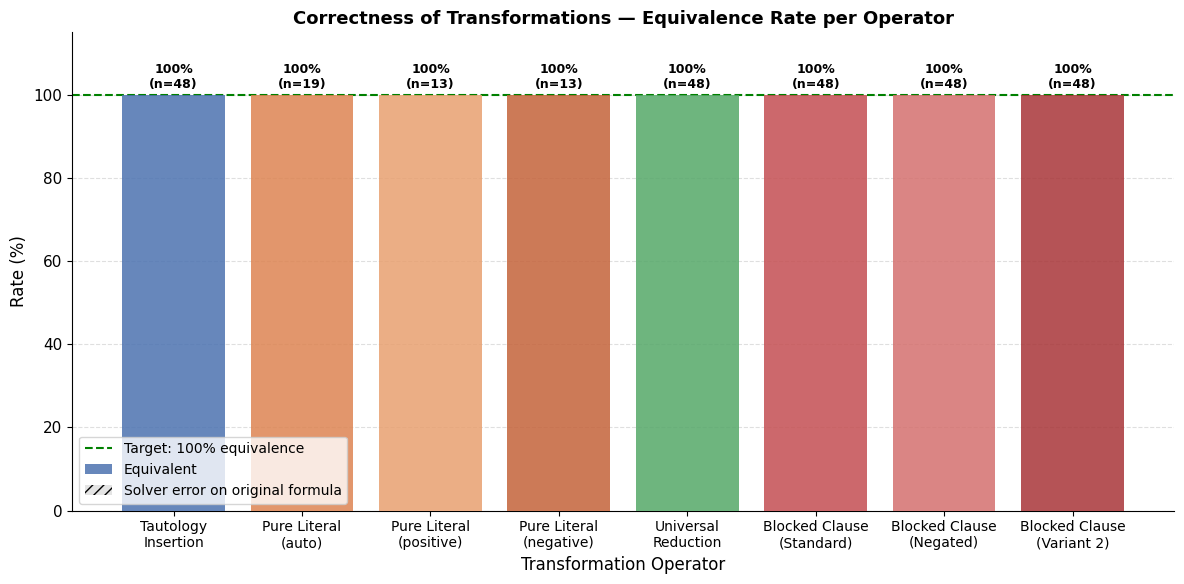

In [118]:
operators = get_operators(df)
labels = [OPERATOR_LABELS.get(op, op) for op in operators]

rates_true = []
rates_error = []
counts = []

for op in operators:
    sub = df[df["operator"] == op]
    n = len(sub)
    counts.append(n)
    if n == 0:
        rates_true.append(0.0)
        rates_error.append(0.0)
        continue

    n_equiv = sub["equivalent"].sum()
    n_error = 0
    if "depqbf_status_original" in sub.columns:
        n_error = (sub["depqbf_status_original"] == "ERROR").sum()

    rates_true.append(float(n_equiv) / n * 100)
    rates_error.append(float(n_error) / n * 100)

colors = [OPERATOR_COLORS.get(op, "#888888") for op in operators]
x = np.arange(len(operators))

fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))

bars = ax.bar(x, rates_true, color=colors, alpha=0.85, zorder=3, label="Equivalent")
ax.bar(x, rates_error, bottom=rates_true, color="lightgray", alpha=0.6, zorder=3,
       label="Solver error on original formula", hatch="///")

for bar, rate_t, n in zip(bars, rates_true, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, rate_t + 1,
            f"{rate_t:.0f}%\n(n={n})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylim(0, 115)
ax.axhline(y=100.0, color="green", linestyle="--", linewidth=1.5,
           label="Target: 100% equivalence", zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_xlabel("Transformation Operator")
ax.set_ylabel("Rate (%)")
ax.set_title("Correctness of Transformations — Equivalence Rate per Operator", fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()

path = PLOT_DIR / "equivalence_rate.png"
fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

## 6. Runtime Analysis: Runtime Ratio Boxplot

The runtime ratio is defined as:

```text
runtime_ratio = runtime_mutant / runtime_original
```

Interpretation:

- ratio < 1.0: mutant is faster than original
- ratio = 1.0: no runtime effect
- ratio > 1.0: mutant is slower than original

Saved: thesis-template/thesis/images/time_ratio_boxplot_depqbf.png


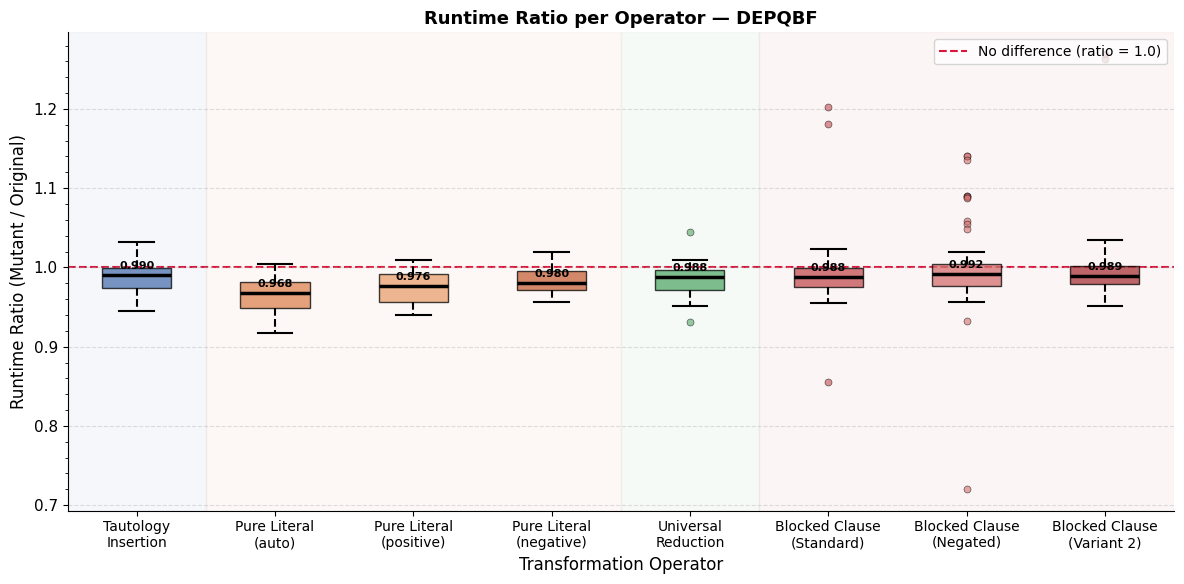

Saved: thesis-template/thesis/images/time_ratio_boxplot_caqe.png


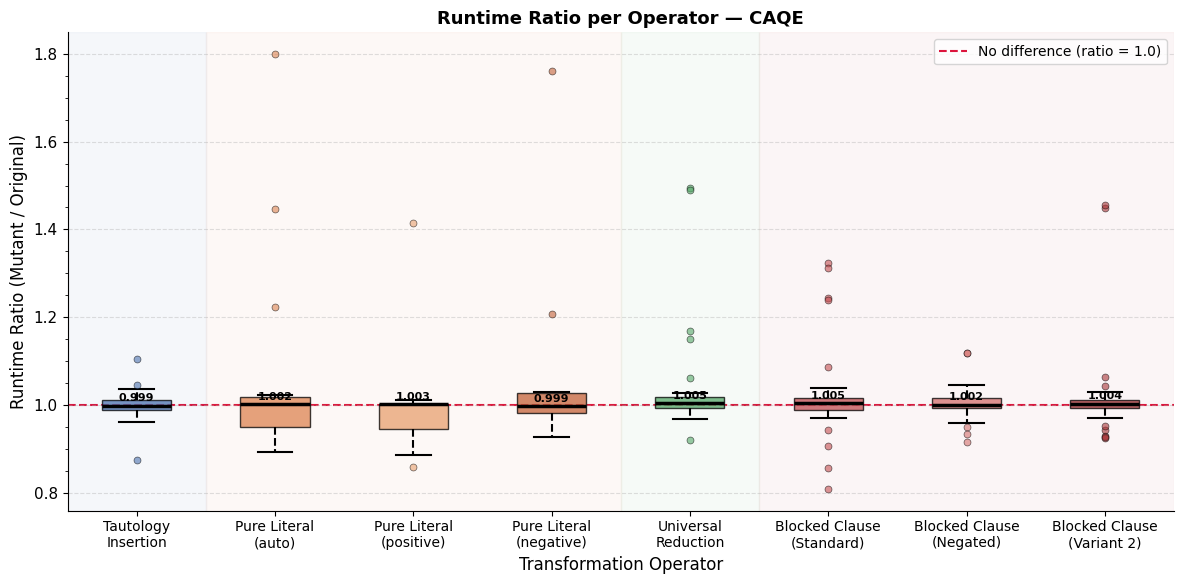

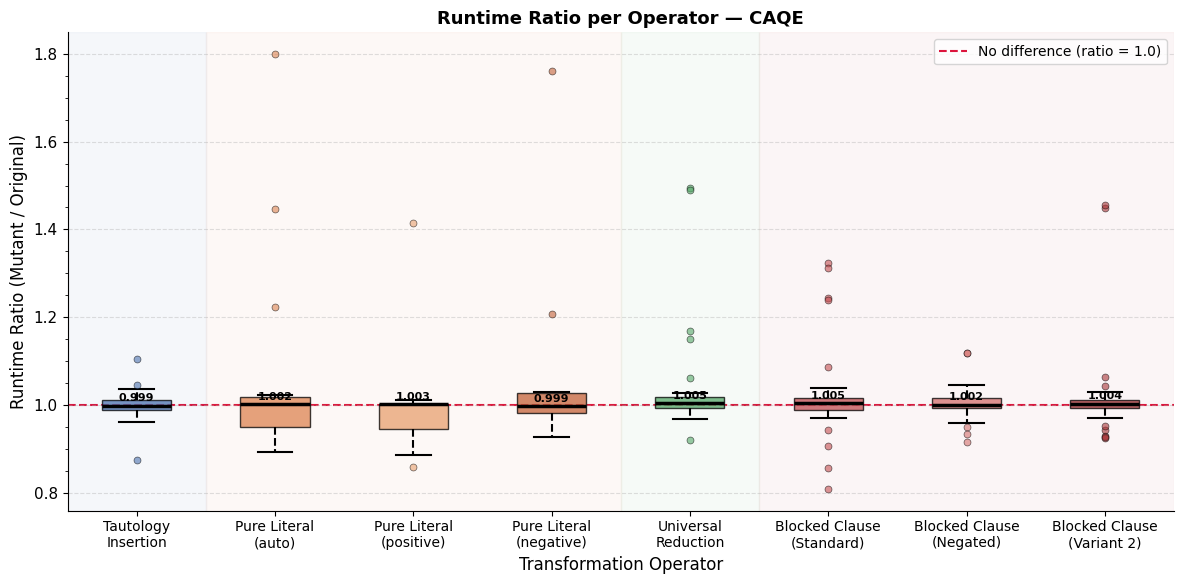

In [119]:
def plot_time_ratio_boxplot(dataframe: pd.DataFrame, solver: str):
    ratio_col = f"{solver}_time_ratio"
    if ratio_col not in dataframe.columns:
        print(f"Column not found: {ratio_col}")
        return None

    operators = get_operators(dataframe)
    data = [dataframe[dataframe["operator"] == op][ratio_col].dropna().tolist() for op in operators]
    pairs = [(op, d) for op, d in zip(operators, data) if len(d) > 0]
    if not pairs:
        print("No data available for boxplot.")
        return None

    operators, data = zip(*pairs)
    colors = [OPERATOR_COLORS.get(op, "#888888") for op in operators]
    labels = [OPERATOR_LABELS.get(op, op) for op in operators]

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    bp = ax.boxplot(
        data,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2.5},
        whiskerprops={"linewidth": 1.5, "linestyle": "--"},
        capprops={"linewidth": 1.5},
        flierprops={"marker": "o", "markersize": 5, "alpha": 0.6, "markeredgewidth": 0.5},
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    for flier, color in zip(bp["fliers"], colors):
        flier.set_markerfacecolor(color)

    ax.axhline(y=1.0, color="crimson", linestyle="--", linewidth=1.5,
               label="No difference (ratio = 1.0)", zorder=0)

    for i, d in enumerate(data):
        median = float(np.median(d))
        ax.text(i + 1, median + 0.005, f"{median:.3f}",
                ha="center", va="bottom", fontsize=8, color="black", fontweight="bold")

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Transformation Operator")
    ax.set_ylabel("Runtime Ratio (Mutant / Original)")
    ax.set_title(f"Runtime Ratio per Operator — {solver.upper()}", fontweight="bold")
    ax.legend(loc="upper right")
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    add_group_bands(ax, list(operators))
    plt.tight_layout()

    path = PLOT_DIR / f"time_ratio_boxplot_{solver}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()
    return fig

plot_time_ratio_boxplot(df_valid, "depqbf")
plot_time_ratio_boxplot(df_valid, "caqe")

## 7. Coverage Analysis

Coverage delta measures how much additional solver code is executed by the transformed formula.

```text
coverage_delta = coverage_mutant - coverage_original
```

A positive delta indicates that the mutant activates additional code paths.

Saved: thesis-template/thesis/images/coverage_delta_line.png


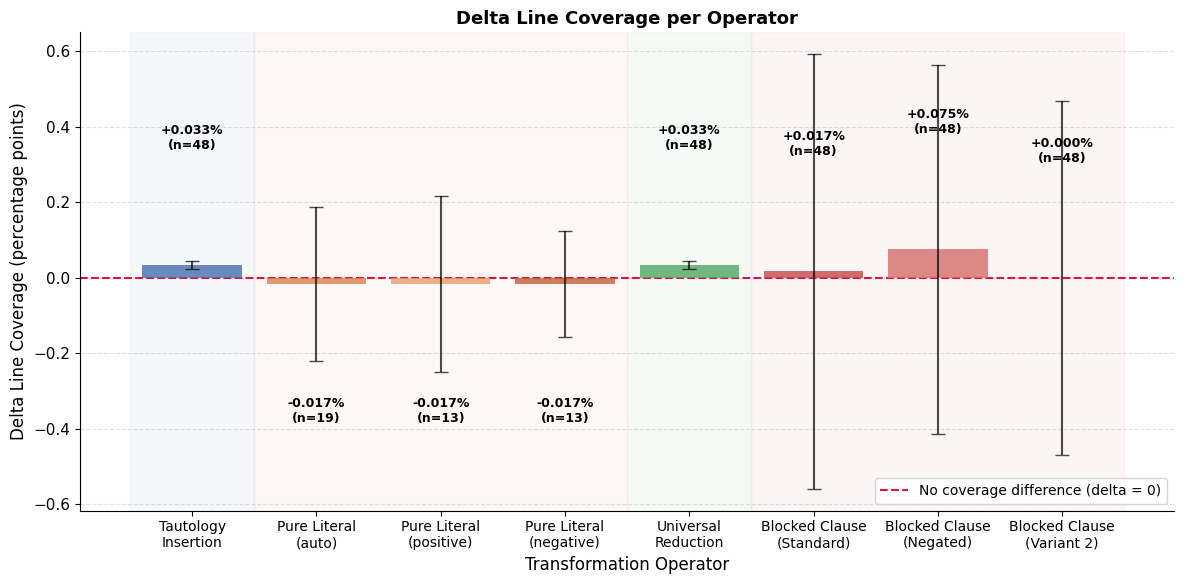

Saved: thesis-template/thesis/images/coverage_delta_branch.png


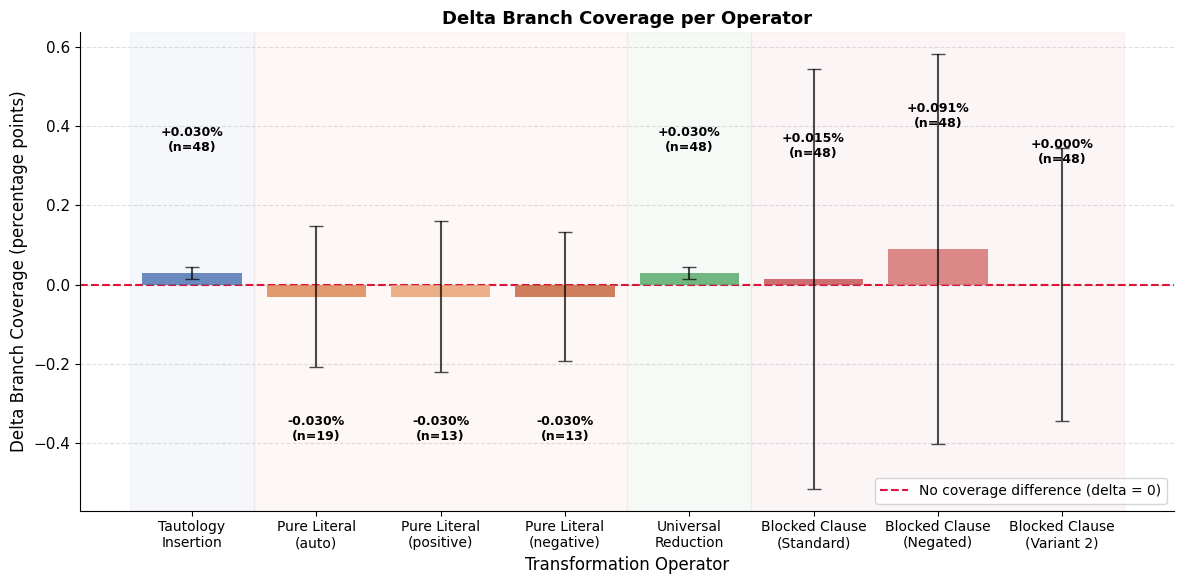

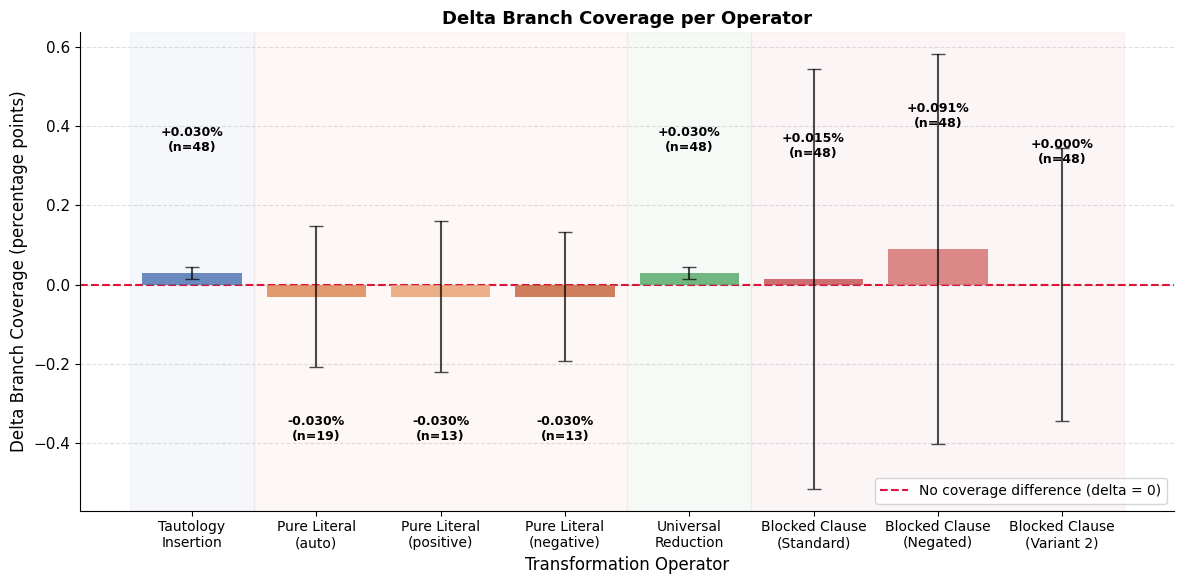

In [120]:
def plot_coverage_delta(dataframe: pd.DataFrame, coverage_type: str):
    delta_col = f"{coverage_type}_coverage_delta"
    if delta_col not in dataframe.columns:
        print(f"Column not found: {delta_col}")
        return None

    operators = get_operators(dataframe)
    medians, stds, counts = [], [], []

    for op in operators:
        vals = dataframe[dataframe["operator"] == op][delta_col].dropna()
        medians.append(vals.median() if len(vals) > 0 else 0.0)
        stds.append(vals.std() if len(vals) > 1 else 0.0)
        counts.append(len(vals))

    colors = [OPERATOR_COLORS.get(op, "#888888") for op in operators]
    labels = [OPERATOR_LABELS.get(op, op) for op in operators]
    x = np.arange(len(operators))

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    bars = ax.bar(x, medians, color=colors, alpha=0.82,
                  yerr=stds, capsize=5,
                  error_kw={"elinewidth": 1.5, "ecolor": "black", "alpha": 0.7},
                  zorder=3)

    max_std = max(stds) if stds else 0
    for bar, val, n in zip(bars, medians, counts):
        offset = max(max_std * 0.05, 0.3)
        if val >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
                    f"+{val:.3f}%\n(n={n})", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, val - offset,
                    f"{val:.3f}%\n(n={n})", ha="center", va="top",
                    fontsize=9, fontweight="bold")

    ax.axhline(y=0.0, color="crimson", linestyle="--", linewidth=1.5,
               label="No coverage difference (delta = 0)", zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Transformation Operator")
    ax.set_ylabel(f"Delta {coverage_type.capitalize()} Coverage (percentage points)")
    ax.set_title(f"Delta {coverage_type.capitalize()} Coverage per Operator", fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    add_group_bands(ax, operators, x_numeric=True)
    plt.tight_layout()

    path = PLOT_DIR / f"coverage_delta_{coverage_type}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()
    return fig

plot_coverage_delta(df_valid, "line")
plot_coverage_delta(df_valid, "branch")

## 8. Solver Comparison: DepQBF vs. CAQE

Saved: thesis-template/thesis/images/solver_comparison.png


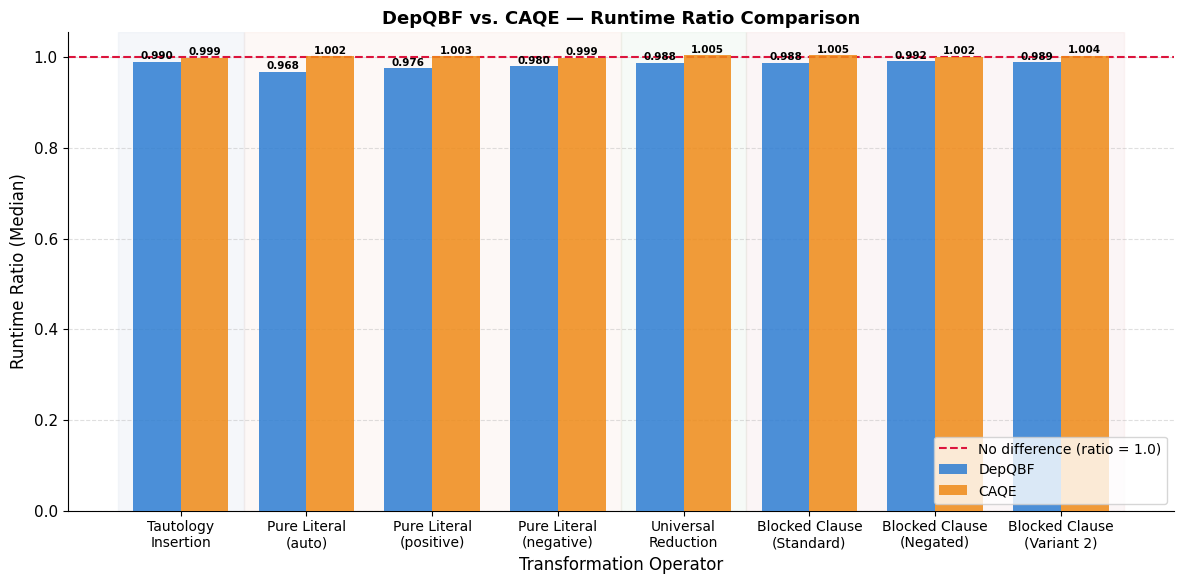

In [121]:
required = ["depqbf_time_ratio", "caqe_time_ratio"]
if not all(col in df_valid.columns for col in required):
    print("Solver comparison cannot be created because required columns are missing.")
else:
    operators = get_operators(df_valid)
    labels = [OPERATOR_LABELS.get(op, op) for op in operators]

    depqbf_medians = [df_valid[df_valid["operator"] == op]["depqbf_time_ratio"].median() for op in operators]
    caqe_medians = [df_valid[df_valid["operator"] == op]["caqe_time_ratio"].median() for op in operators]

    x = np.arange(len(operators))
    width = 0.38

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    bars1 = ax.bar(x - width / 2, depqbf_medians, width, label="DepQBF", color="#2d7dd2", alpha=0.85, zorder=3)
    bars2 = ax.bar(x + width / 2, caqe_medians, width, label="CAQE", color="#ef8a17", alpha=0.85, zorder=3)

    for bars, vals in [(bars1, depqbf_medians), (bars2, caqe_medians)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

    ax.axhline(y=1.0, color="crimson", linestyle="--", linewidth=1.5,
               label="No difference (ratio = 1.0)", zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Transformation Operator")
    ax.set_ylabel("Runtime Ratio (Median)")
    ax.set_title("DepQBF vs. CAQE — Runtime Ratio Comparison", fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    add_group_bands(ax, operators, x_numeric=True)
    plt.tight_layout()

    path = PLOT_DIR / "solver_comparison.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

## 9. Secondary Analysis: Coverage Change vs. Runtime Effect

Saved: thesis-template/thesis/images/scatter_depqbf.png


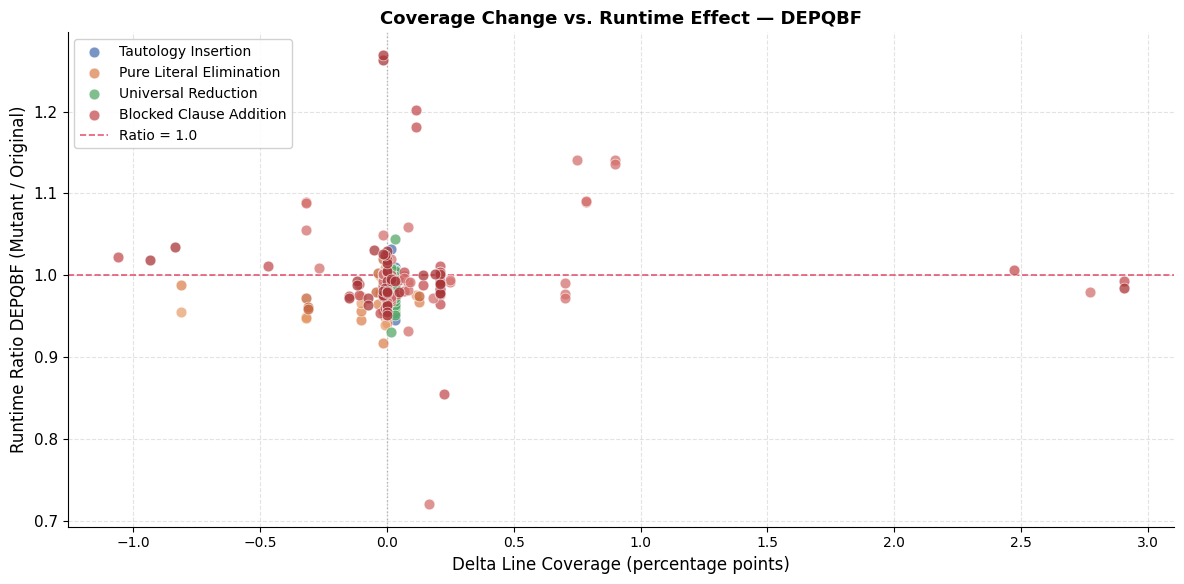

Saved: thesis-template/thesis/images/scatter_caqe.png


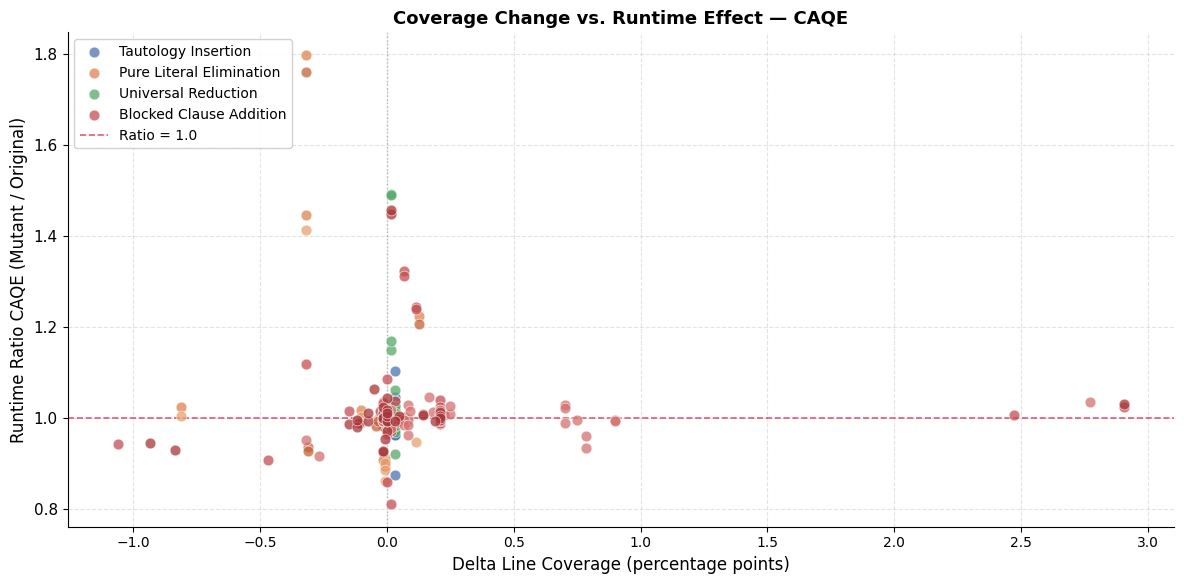

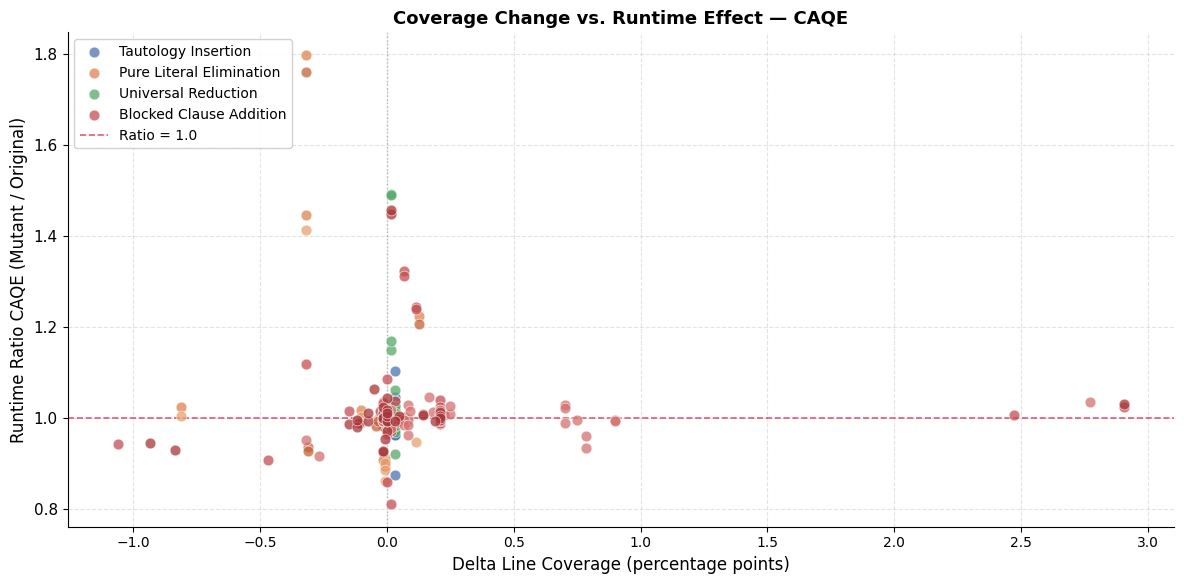

In [122]:
def plot_scatter(dataframe: pd.DataFrame, solver: str):
    ratio_col = f"{solver}_time_ratio"
    delta_col = "line_coverage_delta"

    if ratio_col not in dataframe.columns or delta_col not in dataframe.columns:
        print("Required columns for scatter plot are missing.")
        return None

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    seen_groups = {}

    for op in get_operators(dataframe):
        sub = dataframe[dataframe["operator"] == op]
        if sub.empty:
            continue

        color = OPERATOR_COLORS.get(op, "#888888")
        group_name, group_color = OPERATOR_GROUPS.get(op, (op, color))
        label = group_name if group_name not in seen_groups else "_nolegend_"
        seen_groups[group_name] = group_color

        ax.scatter(sub[delta_col], sub[ratio_col], c=color, alpha=0.75, s=60,
                   zorder=3, label=label, edgecolors="white", linewidths=0.5)

    ax.axhline(y=1.0, color="crimson", linestyle="--", linewidth=1.2,
               alpha=0.7, label="Ratio = 1.0")
    ax.axvline(x=0.0, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)
    ax.set_xlabel("Delta Line Coverage (percentage points)")
    ax.set_ylabel(f"Runtime Ratio {solver.upper()} (Mutant / Original)")
    ax.set_title(f"Coverage Change vs. Runtime Effect — {solver.upper()}", fontweight="bold")
    ax.legend(loc="upper left", framealpha=0.9)
    ax.grid(linestyle="--", alpha=0.35)
    plt.tight_layout()

    path = PLOT_DIR / f"scatter_{solver}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()
    return fig

plot_scatter(df_valid, "depqbf")
plot_scatter(df_valid, "caqe")

## 10. Group-wise Coverage/Runtime Trend Analysis

Saved: thesis-template/thesis/images/coverage_vs_ratio_depqbf.png


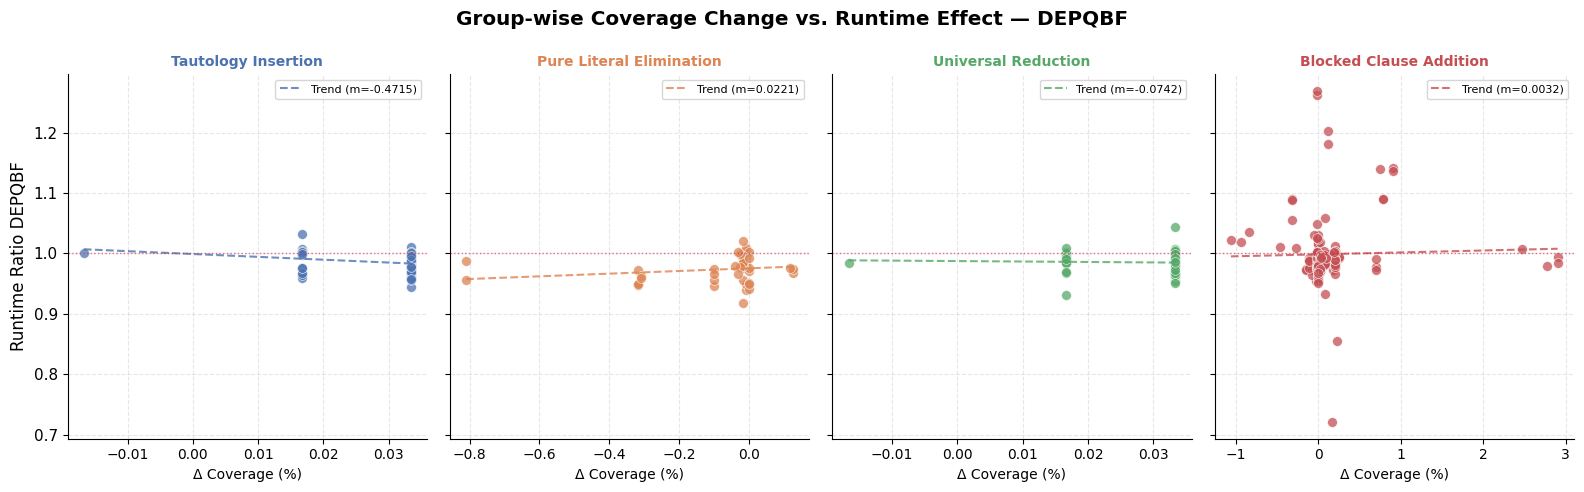

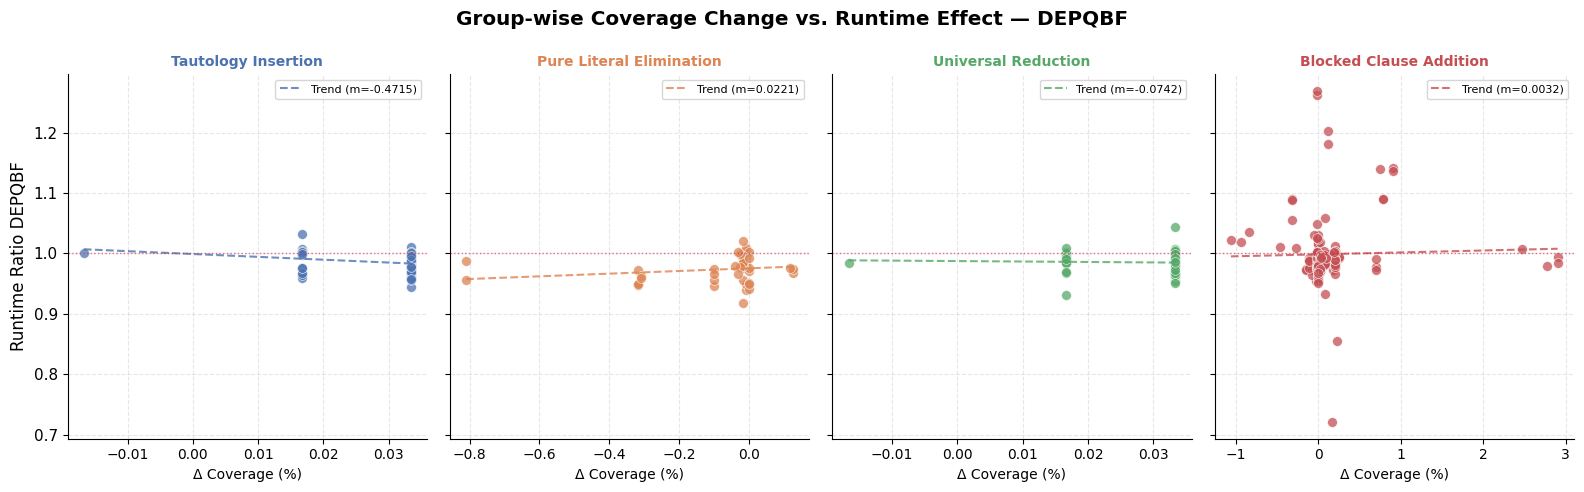

In [123]:
def plot_coverage_vs_ratio(dataframe: pd.DataFrame, solver: str):
    ratio_col = f"{solver}_time_ratio"
    delta_col = "line_coverage_delta"

    if ratio_col not in dataframe.columns or delta_col not in dataframe.columns:
        print("Required columns are missing.")
        return None

    groups = {
        "Tautology Insertion": ["tautology_insertion"],
        "Pure Literal Elimination": ["pure_literal_gen_auto", "pure_literal_gen_pos", "pure_literal_gen_neg"],
        "Universal Reduction": ["universal_reduction_trigger"],
        "Blocked Clause Addition": ["blocked_clause_insertion", "blocked_clause_insertion_neg", "blocked_clause_insertion_v1"],
    }

    group_colors = {
        "Tautology Insertion": "#4C72B0",
        "Pure Literal Elimination": "#DD8452",
        "Universal Reduction": "#55A868",
        "Blocked Clause Addition": "#C44E52",
    }

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

    for ax, (group_name, ops) in zip(axes, groups.items()):
        sub = dataframe[dataframe["operator"].isin(ops)]
        color = group_colors[group_name]

        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="gray")
        else:
            ax.scatter(sub[delta_col], sub[ratio_col], c=color, alpha=0.75, s=50,
                       edgecolors="white", linewidths=0.5)

            clean = sub[[delta_col, ratio_col]].dropna()
            if len(clean) > 2:
                x_arr = clean[delta_col].values
                y_arr = clean[ratio_col].values
                m, b = np.polyfit(x_arr, y_arr, 1)
                x_line = np.linspace(x_arr.min(), x_arr.max(), 50)
                ax.plot(x_line, m * x_line + b, color=color, linewidth=1.5,
                        linestyle="--", alpha=0.8, label=f"Trend (m={m:.4f})")
                ax.legend(fontsize=8)

        ax.axhline(y=1.0, color="crimson", linestyle=":", linewidth=1.0, alpha=0.6)
        ax.set_xlabel("Δ Coverage (%)", fontsize=10)
        ax.set_title(group_name, fontsize=10, fontweight="bold", color=color)
        ax.grid(linestyle="--", alpha=0.3)

    axes[0].set_ylabel(f"Runtime Ratio {solver.upper()}")
    fig.suptitle(f"Group-wise Coverage Change vs. Runtime Effect — {solver.upper()}", fontweight="bold")
    plt.tight_layout()

    path = PLOT_DIR / f"coverage_vs_ratio_{solver}.png"
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()
    return fig

plot_coverage_vs_ratio(df_valid, "depqbf")

## 11. Aggregated Summary Table

In [124]:
summary_rows = []

for op in get_operators(df_valid):
    sub = df_valid[df_valid["operator"] == op]
    if sub.empty:
        continue

    depqbf_ratio = sub["depqbf_time_ratio"].median() if "depqbf_time_ratio" in sub.columns else np.nan
    caqe_ratio   = sub["caqe_time_ratio"].median()   if "caqe_time_ratio"   in sub.columns else np.nan
    line_delta   = sub["line_coverage_delta"].median()   if "line_coverage_delta"   in sub.columns else np.nan
    branch_delta = sub["branch_coverage_delta"].median() if "branch_coverage_delta" in sub.columns else np.nan

    summary_rows.append({
        "Operator":                    OPERATOR_LABELS.get(op, op).replace("\n", " "),
        "n":                           len(sub),
        "Median Runtime Ratio DepQBF": depqbf_ratio,
        "Median Runtime Ratio CAQE":   caqe_ratio,
        "Median Δ Line Coverage":      line_delta,
        "Median Δ Branch Coverage":    branch_delta,
        "Activated Mechanism":         MECHANISMS.get(op, "—"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = Path("results/data/summary_table.csv")
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(summary_path, index=False)

print(f"Saved: {summary_path}")
summary_df

Saved: results/data/summary_table.csv


,Operator,n,Median Runtime Ratio DepQBF,Median Runtime Ratio CAQE,Median Δ Line Coverage,Median Δ Branch Coverage,Activated Mechanism
0,Tautology Insertion,48,0.989875,0.999258,0.033381,0.030180,Tautology preprocessing
1,Pure Literal (auto),19,0.967809,1.002252,-0.016690,-0.030180,Pure literal elimination
2,Pure Literal (positive),13,0.976224,1.002661,-0.016690,-0.030180,Pure literal elimination
3,Pure Literal (negative),13,0.980082,0.999007,-0.016690,-0.030180,Pure literal elimination
4,Universal Reduction,48,0.987973,1.004515,0.033381,0.030180,Universal reduction / quantifier propagation
5,Blocked Clause (Standard),48,0.988052,1.004921,0.016690,0.015090,Blocked clause addition / BCE
6,Blocked Clause (Negated),48,0.991902,1.001794,0.075106,0.090539,Blocked clause addition / BCE
7,Blocked Clause (Variant 2),48,0.988746,1.003721,0.000000,0.000000,Blocked clause addition / BCE
